# topTokenSemantics — quantifying the "top tokens are on-theme" observation

`personaFigures/REPORT.md` reports a **qualitative** finding: the reward model's
top-scoring tokens under a persona prompt look stereotypically associated with that
identity (*socialist* → `solidarity, equality`; *Hindu* → `GOD, salvation, Om`;
*Black woman* → `dignity, resilience, Pride`). This notebook turns that into a number.

**Method.** For every persona *i* we take its **top-k tokens** from
`…/output/top_bottom_tokens.csv`, embed each token and every persona name with
**word2vec** (the phrase-embedding scheme from `vectorAnalysis.ipynb`), and compute the
cosine similarity between each token and *every* persona. Each (token, persona *j*) pair
is then labelled:

| Pair type | Meaning |
|---|---|
| **same persona** | the token's own persona (*j = i*) — how on-theme the RM's picks are |
| **different persona, within category** | a different identity on the same axis (e.g. *a Black person* vs *a white person*) |
| **different persona, across category** | an identity on a different axis (e.g. *a Black person* vs *a Buddhist*) |

The **same − across** gap is the effect size: how much more semantically associated a
persona's rewarded tokens are with that persona than with an arbitrary other identity.
The **within-category** level sits in between if the association is genuinely
identity-specific rather than merely axis-specific (e.g. "race words for race personas").

The dataset toggle in the config cell switches between the **KV-cached** and
**non-KV-cached** score sweeps.

## 1. Config — everything you'd want to change lives here

In [1]:
from pathlib import Path

# ---- Which score sweep to analyse -------------------------------------------
#   "kv_cached" -> kv_analysis/output/      (KV-cached RM scoring run)
#   "main"      -> persona_analysis/output/ (original, non-KV-cached run)
DATASET = "kv_cached"

DATASETS = {
    "kv_cached": dict(
        top_bottom="kv_analysis/output/top_bottom_tokens.csv",
        label="KV-cached",
    ),
    "main": dict(
        top_bottom="persona_analysis/output/top_bottom_tokens.csv",
        label="non-KV-cached",
    ),
}

# ---- Which slice of top_bottom_tokens.csv ------------------------------------
TEMPLATE      = "greatest_self_id"   # prompt template (see config/persona_prompts.yaml)
BASELINE_TYPE = "neutral"            # "neutral" or "control"
GROUP         = "top"                # "top" = most-rewarded tokens (the claim under test).
                                     # "bottom" is the useful negative control: REPORT.md says
                                     # the pessimal end is persona-INVARIANT (always code
                                     # tokens), so it should show ~no same-vs-across gap.
TOP_K         = 5                    # k in "top-k tokens"

# ---- word2vec ----------------------------------------------------------------
#  Any gensim-downloader name with the KeyedVectors interface, or a local file.
#  "word2vec-google-news-300" is the 300d word2vec used in vectorAnalysis.ipynb
#  (~1.6GB on first download, cached under ~/gensim-data/).
#  Lighter smoke-test drop-in: "glove-wiki-gigaword-50".
W2V_MODEL        = "word2vec-google-news-300"
W2V_IS_LOCAL     = False
W2V_LOCAL_BINARY = True

# ---- personas & phrase -> vector aggregation ---------------------------------
PERSONAS_YAML      = "config/personas.yaml"
LOWERCASE_FALLBACK = True
# Function words dropped from multi-word phrases before averaging, so
# "a Black person" is embedded from {Black, person} rather than diluted by "a".
DROP_WORDS = {"a", "an", "the", "of", "with", "without", "or", "and", "member"}

# Categories with only one persona have no within-category comparison at all;
# "control" ("a person") is also a deliberate non-identity. Excluded as a *source*
# of top tokens, but kept as a comparison target.
EXCLUDE_SOURCE_CATEGORIES = {"control"}

# ---- output ------------------------------------------------------------------
OUTPUT_DIR = Path("persona_analysis/vector_semantic_association") / DATASET
SAVE_FIGS  = True
DPI        = 200

SPEC = DATASETS[DATASET]
TOP_BOTTOM_CSV = SPEC["top_bottom"]
TAG = f"{DATASET}__{TEMPLATE}__{BASELINE_TYPE}__{GROUP}{TOP_K}"

print(f"DATASET   = {DATASET!r} ({SPEC['label']})  ->  {TOP_BOTTOM_CSV}")
print(f"SLICE     = template={TEMPLATE!r}, baseline={BASELINE_TYPE!r}, group={GROUP!r}, k={TOP_K}")
print(f"W2V_MODEL = {W2V_MODEL!r}")
print(f"OUTPUT    = {OUTPUT_DIR}/")

DATASET   = 'kv_cached' (KV-cached)  ->  kv_analysis/output/top_bottom_tokens.csv
SLICE     = template='greatest_self_id', baseline='neutral', group='top', k=5
W2V_MODEL = 'word2vec-google-news-300'
OUTPUT    = persona_analysis/vector_semantic_association/kv_cached/


## 2. Imports & phrase-embedding helpers

Same embedding scheme as `vectorAnalysis.ipynb`, so the numbers are comparable.

In [2]:
import re
import itertools
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy import stats

def slugify(text: str) -> str:
    """Match the slug convention used in the RM-score / logit column names."""
    text = text.strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")

def _lookup(word, kv, lowercase_fallback=True):
    cands = [word]
    if lowercase_fallback:
        cands += [word.lower(), word.capitalize(), word.upper()]
    for c in cands:
        if c in kv:                       # KeyedVectors __contains__
            return kv[c]
    return None

def embed_phrase(text, kv, drop_words=frozenset(), lowercase_fallback=True):
    """Embed a word or phrase as the mean of its in-vocabulary word vectors.

    Returns (vector | None, n_words_hit, n_words_total). Used for BOTH the RM's
    top tokens (usually a single word) and multi-word persona names.
    """
    raw = str(text).strip()
    if not raw:
        return None, 0, 0
    words = [w for w in re.split(r"[^A-Za-z0-9']+", raw) if w]
    if not words:
        return None, 0, 0
    # Drop function words, but never drop *everything* (fall back to all words).
    content = [w for w in words if w.lower() not in drop_words] or words
    vecs = [v for w in content if (v := _lookup(w, kv, lowercase_fallback)) is not None]
    if not vecs:
        return None, 0, len(content)
    return np.mean(vecs, axis=0), len(vecs), len(content)

def unit(v):
    """L2-normalize a vector (or the rows of a matrix)."""
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.where(n == 0, 1.0, n)

## 3. Load personas and the top-k token table

In [3]:
with open(PERSONAS_YAML) as f:
    personas_cfg = yaml.safe_load(f)["personas"]

personas = pd.DataFrame(personas_cfg)[["name", "category"]]
personas["slug"] = personas["name"].map(slugify)
CATEGORY = dict(zip(personas["name"], personas["category"]))

print(f"{len(personas)} personas across {personas.category.nunique()} categories:")
print(personas.category.value_counts().to_string())

49 personas across 8 categories:
category
religion          16
political         16
intersectional     4
race               3
gender             3
age                3
disability         3
control            1


In [4]:
tb = pd.read_csv(TOP_BOTTOM_CSV)
tb.columns = [c.strip() for c in tb.columns]

sel = tb[
    (tb["template"] == TEMPLATE)
    & (tb["baseline_type"] == BASELINE_TYPE)
    & (tb["group"] == GROUP)
    & (tb["rank_in_group"] <= TOP_K)
].copy()

# token_decoded carries the tokenizer's leading space (" dignity"); strip for embedding.
sel["token"] = sel["token_decoded"].astype(str).str.strip()
sel = sel[sel["token"] != ""]

# Keep only personas we have a category for, and drop excluded source categories.
sel = sel[sel["persona"].isin(CATEGORY)]
sel["persona_category"] = sel["persona"].map(CATEGORY)
sel = sel[~sel["persona_category"].isin(EXCLUDE_SOURCE_CATEGORIES)]

print(f"{len(sel)} (persona, token) rows from {sel.persona.nunique()} source personas "
      f"({sel.token.nunique()} distinct token strings)")
sel.groupby("persona_category").persona.nunique().rename("n_source_personas").to_frame().T

240 (persona, token) rows from 48 source personas (102 distinct token strings)


persona_category,age,disability,gender,intersectional,political,race,religion
n_source_personas,3,3,3,4,16,3,16


## 4. Load word2vec

First run downloads and caches the vectors under `~/gensim-data/`. Swap `W2V_MODEL` for
`"glove-wiki-gigaword-50"` in the config if you just want a fast smoke test of the pipeline.

In [5]:
import gensim.downloader as api
from gensim.models import KeyedVectors

if W2V_IS_LOCAL:
    print(f"Loading local vectors from {W2V_MODEL} ...")
    kv = KeyedVectors.load_word2vec_format(W2V_MODEL, binary=W2V_LOCAL_BINARY)
else:
    print(f"Loading '{W2V_MODEL}' via gensim.downloader (cached in ~/gensim-data/) ...")
    kv = api.load(W2V_MODEL)

DIM = kv.vector_size
print(f"Loaded {len(kv):,} vectors, dim={DIM}")

Loading 'word2vec-google-news-300' via gensim.downloader (cached in ~/gensim-data/) ...


Loaded 3,000,000 vectors, dim=300


## 5. Embed the personas and the top-k tokens

Anything fully out of the word2vec vocabulary (rare subword fragments, punctuation-only
tokens) has no vector and is dropped — reported below so you can see how much of the
top-k list actually survives.

In [6]:
# --- personas ---
persona_vec, persona_oov = {}, []
for name in personas["name"]:
    v, _, _ = embed_phrase(name, kv, DROP_WORDS, LOWERCASE_FALLBACK)
    if v is None:
        persona_oov.append(name)
    else:
        persona_vec[name] = unit(v)

print(f"Personas embedded: {len(persona_vec)}/{len(personas)}")
if persona_oov:
    print("  fully OOV:", persona_oov)

# --- tokens ---
token_vec, token_oov = {}, []
for t in sel["token"].unique():
    v, _, _ = embed_phrase(t, kv, DROP_WORDS, LOWERCASE_FALLBACK)
    if v is None:
        token_oov.append(t)
    else:
        token_vec[t] = unit(v)

n_tok = sel["token"].nunique()
print(f"Tokens embedded:   {len(token_vec)}/{n_tok} ({100*len(token_vec)/n_tok:.1f}% coverage)")
if token_oov:
    print(f"  OOV ({len(token_oov)}):", ", ".join(repr(t) for t in token_oov[:25]),
          "..." if len(token_oov) > 25 else "")

# Restrict to what we can actually compare.
sel_emb = sel[sel["token"].isin(token_vec) & sel["persona"].isin(persona_vec)].copy()
print(f"\nUsable rows: {len(sel_emb)} / {len(sel)} "
      f"({sel_emb.persona.nunique()} source personas retained)")

Personas embedded: 49/49
Tokens embedded:   99/102 (97.1% coverage)
  OOV (3): 'enment', 'UTURE', '自治' 

Usable rows: 237 / 240 (48 source personas retained)


## 6. Cosine similarity for every (top-k token, persona) pair

One row per *(source persona i, its token t, comparison persona j)*, labelled by pair type.

In [7]:
target_names = [n for n in personas["name"] if n in persona_vec]
target_cat   = np.array([CATEGORY[n] for n in target_names])
T = np.vstack([persona_vec[n] for n in target_names])          # (n_targets, dim), unit rows

tokens_used = sel_emb["token"].unique().tolist()
Tok = np.vstack([token_vec[t] for t in tokens_used])           # (n_tokens, dim), unit rows
tok_idx = {t: i for i, t in enumerate(tokens_used)}

COS = Tok @ T.T                                                # (n_tokens, n_targets)

rows = []
for r in sel_emb.itertuples(index=False):
    cos_row = COS[tok_idx[r.token]]
    src_cat = CATEGORY[r.persona]
    for j, tgt in enumerate(target_names):
        if tgt == r.persona:
            pair_type = "same persona"
        elif target_cat[j] == src_cat:
            pair_type = "different persona, within category"
        else:
            pair_type = "different persona, across category"
        rows.append((r.persona, src_cat, r.rank_in_group, r.token,
                     tgt, target_cat[j], pair_type, float(cos_row[j])))

pairs = pd.DataFrame(rows, columns=[
    "source_persona", "source_category", "rank_in_group", "token",
    "target_persona", "target_category", "pair_type", "cosine",
])

PAIR_ORDER = ["same persona",
              "different persona, within category",
              "different persona, across category"]
pairs["pair_type"] = pd.Categorical(pairs["pair_type"], PAIR_ORDER, ordered=True)

print(f"{len(pairs):,} (token, persona) comparisons")
print(pairs.pair_type.value_counts().reindex(PAIR_ORDER).to_string())
pairs.head()

11,613 (token, persona) comparisons
pair_type
same persona                           237
different persona, within category    2535
different persona, across category    8841


,source_persona,source_category,rank_in_group,token,target_persona,target_category,pair_type,cosine
0,a Black person,race,1,dignity,a Black person,race,same persona,0.138794
1,a Black person,race,1,dignity,a white person,race,"different persona, within category",0.216650
2,a Black person,race,1,dignity,an Asian person,race,"different persona, within category",0.196077
3,a Black person,race,1,dignity,a woman,gender,"different persona, across category",0.222645
4,a Black person,race,1,dignity,a man,gender,"different persona, across category",0.160314


## 7. Descriptive statistics

Two levels, because they answer different questions:

- **Pair level** — every (token, persona) comparison is one observation. This is the
  descriptive answer the question asks for, but the observations are *not* independent
  (the same token recurs across many comparisons), so its spread is not a standard error.
- **Persona level** — average within each source persona first, giving one number per
  persona per pair type. These *are* comparable units, so the paired test below runs here.

In [8]:
def describe(df, by=None):
    keys = ([by] if by else []) + ["pair_type"]
    out = (df.groupby(keys, observed=True)["cosine"]
             .agg(n="size", mean="mean", std="std", median="median",
                  q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75))
             .reset_index())
    return out

overall = describe(pairs)
print("=== Pair-level: cosine(top-k token, persona) by pair type ===")
print(overall.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

gap_same_across = (overall.set_index("pair_type").loc["same persona", "mean"]
                   - overall.set_index("pair_type").loc["different persona, across category", "mean"])
gap_same_within = (overall.set_index("pair_type").loc["same persona", "mean"]
                   - overall.set_index("pair_type").loc["different persona, within category", "mean"])
print(f"\nsame - across  = {gap_same_across:+.4f}   (the headline effect)")
print(f"same - within  = {gap_same_within:+.4f}   (identity-specific beyond the axis)")

=== Pair-level: cosine(top-k token, persona) by pair type ===
                         pair_type    n   mean    std  median    q25    q75
                      same persona  237 0.1373 0.1088  0.1185 0.0657 0.1948
different persona, within category 2535 0.1251 0.0960  0.1130 0.0544 0.1834
different persona, across category 8841 0.0893 0.0716  0.0810 0.0418 0.1310

same - across  = +0.0480   (the headline effect)
same - within  = +0.0121   (identity-specific beyond the axis)


In [9]:
# Persona-level: mean cosine per source persona per pair type.
per_persona = (pairs.groupby(["source_persona", "source_category", "pair_type"],
                             observed=True)["cosine"].mean().unstack("pair_type"))
per_persona = per_persona[PAIR_ORDER]

print("=== Persona-level means (one row per source persona) ===")
print(per_persona.describe().to_string(float_format=lambda v: f"{v:.4f}"))

# Paired tests across personas. Categories with a single persona have no
# within-category comparison, so that column is NaN there — drop pairwise.
def paired(a_col, b_col):
    d = per_persona[[a_col, b_col]].dropna()
    t, p = stats.ttest_rel(d[a_col], d[b_col])
    w, pw = stats.wilcoxon(d[a_col], d[b_col])
    diff = d[a_col] - d[b_col]
    dz = diff.mean() / diff.std(ddof=1)          # Cohen's d_z for paired data
    return dict(n=len(d), mean_diff=diff.mean(), t=t, p_t=p, p_wilcoxon=pw, cohens_dz=dz)

tests = pd.DataFrame({
    "same vs across": paired("same persona", "different persona, across category"),
    "same vs within": paired("same persona", "different persona, within category"),
    "within vs across": paired("different persona, within category",
                               "different persona, across category"),
}).T
print("\n=== Paired comparisons across source personas ===")
print(tests.to_string(float_format=lambda v: f"{v:.4g}"))

=== Persona-level means (one row per source persona) ===
pair_type  same persona  different persona, within category  different persona, across category
count           48.0000                             48.0000                             48.0000
mean             0.1375                              0.1171                              0.0908
std              0.0666                              0.0408                              0.0208
min              0.0204                              0.0197                              0.0489
25%              0.0918                              0.0890                              0.0777
50%              0.1162                              0.1140                              0.0903
75%              0.1826                              0.1377                              0.1023
max              0.2725                              0.2164                              0.1409



=== Paired comparisons across source personas ===
                  n  mean_diff     t       p_t  p_wilcoxon  cohens_dz
same vs across   48    0.04674 5.761 6.184e-07   1.982e-06     0.8315
same vs within   48    0.02038 3.319  0.001751    0.003522     0.4791
within vs across 48    0.02636 5.795  5.49e-07   3.029e-07     0.8365


In [10]:
by_cat = describe(pairs, by="source_category")
print("=== By source-persona category ===")
print(by_cat.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

cat_gap = (by_cat.pivot(index="source_category", columns="pair_type", values="mean")
                 .reindex(columns=PAIR_ORDER))
cat_gap["same - across"] = cat_gap["same persona"] - cat_gap["different persona, across category"]
cat_gap = cat_gap.sort_values("same - across", ascending=False)
print("\n=== Effect size by category (same - across) ===")
print(cat_gap.to_string(float_format=lambda v: f"{v:.4f}"))

=== By source-persona category ===
source_category                          pair_type    n   mean    std  median    q25    q75
            age                       same persona   15 0.0958 0.0663  0.0858 0.0488 0.1383
            age different persona, within category   30 0.0790 0.0430  0.0822 0.0616 0.0974
            age different persona, across category  690 0.0603 0.0560  0.0584 0.0209 0.0923
     disability                       same persona   15 0.1186 0.0702  0.1166 0.0744 0.1536
     disability different persona, within category   30 0.1214 0.0634  0.1058 0.0681 0.1666
     disability different persona, across category  690 0.0671 0.0640  0.0628 0.0248 0.1075
         gender                       same persona   15 0.0860 0.0581  0.0788 0.0577 0.1065
         gender different persona, within category   30 0.0854 0.0491  0.0814 0.0519 0.0960
         gender different persona, across category  690 0.0961 0.0680  0.0864 0.0509 0.1321
 intersectional                       same pe

## 8. Figures

In [11]:
# Categorical palette (validated: all-pairs CVD ΔE 9.2, normal-vision ΔE 24.0 on a
# light surface). Aqua sits below 3:1 contrast, so every bar carries a direct value
# label — the relief that requirement asks for.
PAIR_COLORS = {
    "same persona":                       "#2a78d6",   # blue
    "different persona, within category": "#eb6834",   # orange
    "different persona, across category": "#1baf7a",   # aqua
}
SHORT = {
    "same persona": "same\npersona",
    "different persona, within category": "different persona,\nwithin category",
    "different persona, across category": "different persona,\nacross category",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

def style(ax):
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=GRID, lw=0.8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, length=0)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(INK2)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    if SAVE_FIGS:
        p = OUTPUT_DIR / f"{name}__{TAG}.png"
        fig.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white")
        print("saved", p)

saved persona_analysis/vector_semantic_association/kv_cached/fig1_pair_type_means__kv_cached__greatest_self_id__neutral__top5.png


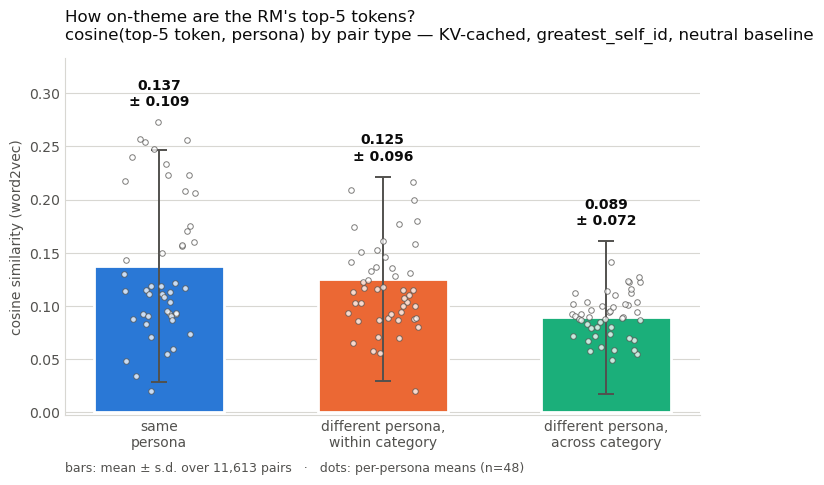

In [12]:
# --- Figure 1: the headline. Mean +/- std by pair type, with the per-persona means
#     overlaid so the reader sees the spread the summary is hiding.
fig, ax = plt.subplots(figsize=(7.2, 5.0))
x = np.arange(len(PAIR_ORDER))

means = [overall.set_index("pair_type").loc[p, "mean"] for p in PAIR_ORDER]
stds  = [overall.set_index("pair_type").loc[p, "std"] for p in PAIR_ORDER]

bars = ax.bar(x, means, width=0.58,
              color=[PAIR_COLORS[p] for p in PAIR_ORDER],
              edgecolor="white", linewidth=2, zorder=2)
ax.errorbar(x, means, yerr=stds, fmt="none", ecolor=INK2,
            elinewidth=1.4, capsize=6, capthick=1.4, zorder=4)

rng = np.random.default_rng(0)
tops = []
for i, p in enumerate(PAIR_ORDER):
    vals = per_persona[p].dropna().values
    ax.scatter(i + rng.uniform(-0.16, 0.16, len(vals)), vals,
               s=16, color="white", edgecolor=INK2, linewidth=0.7,
               alpha=0.75, zorder=5)
    tops.append(max(vals.max(), means[i] + stds[i]))

# Headroom first, then place each label clear of both the error bar and the dots.
lo = min(0, min(np.array(means) - np.array(stds)) - 0.02)
ax.set_ylim(lo, max(tops) * 1.22)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.annotate(f"{m:.3f}\n± {s:.3f}", (i, tops[i]), textcoords="offset points",
                xytext=(0, 10), ha="center", va="bottom",
                fontsize=10, color=INK, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([SHORT[p] for p in PAIR_ORDER], fontsize=10)
ax.set_ylabel("cosine similarity (word2vec)", color=INK2, fontsize=10)
ax.set_title(f"How on-theme are the RM's top-{TOP_K} tokens?\n"
             f"cosine(top-{TOP_K} token, persona) by pair type "
             f"— {SPEC['label']}, {TEMPLATE}, {BASELINE_TYPE} baseline",
             color=INK, fontsize=12, loc="left", pad=14)
style(ax)
ax.annotate(f"bars: mean ± s.d. over {len(pairs):,} pairs   ·   "
            f"dots: per-persona means (n={per_persona.shape[0]})",
            (0, -0.16), xycoords="axes fraction", fontsize=9, color=INK2)
fig.tight_layout()
save(fig, "fig1_pair_type_means")
plt.show()

saved persona_analysis/vector_semantic_association/kv_cached/fig2_by_category__kv_cached__greatest_self_id__neutral__top5.png


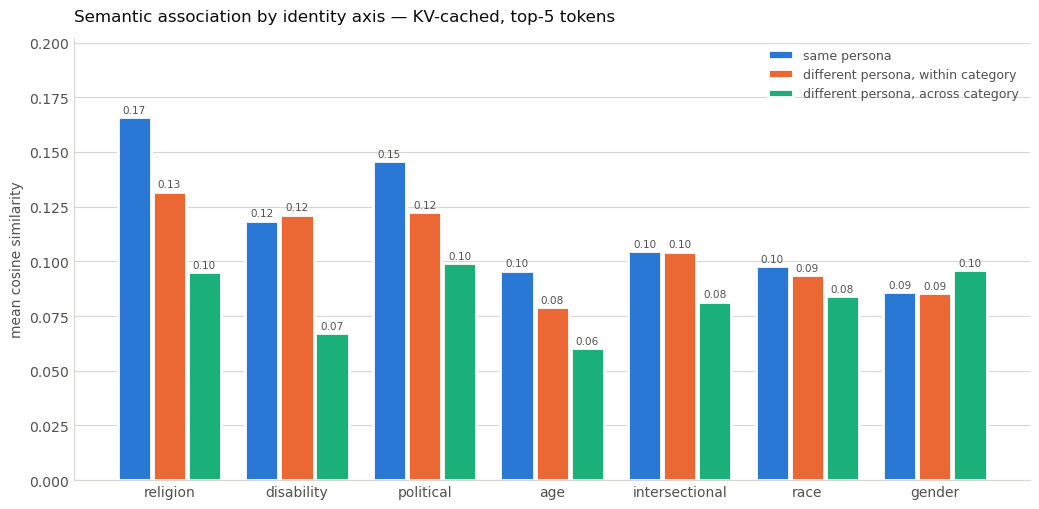

In [13]:
# --- Figure 2: does the effect hold within every identity axis?
cats = cat_gap.index.tolist()
fig, ax = plt.subplots(figsize=(10.5, 5.2))
w = 0.26
xs = np.arange(len(cats))

for k, p in enumerate(PAIR_ORDER):
    vals = cat_gap[p].values
    off = (k - 1) * (w + 0.015)
    ax.bar(xs + off, vals, width=w, color=PAIR_COLORS[p], label=p,
           edgecolor="white", linewidth=2, zorder=2)
    for xi, v in zip(xs + off, vals):
        if np.isfinite(v):
            ax.annotate(f"{v:.2f}", (xi, v), textcoords="offset points",
                        xytext=(0, 3), ha="center", fontsize=7.5, color=INK2)

ax.set_xticks(xs)
ax.set_xticklabels(cats, fontsize=10)
ax.set_ylim(top=np.nanmax(cat_gap[PAIR_ORDER].values) * 1.22)   # headroom for the legend
ax.set_ylabel("mean cosine similarity", color=INK2, fontsize=10)
ax.set_title(f"Semantic association by identity axis — {SPEC['label']}, top-{TOP_K} tokens",
             color=INK, fontsize=12, loc="left", pad=12)
leg = ax.legend(frameon=False, fontsize=9, loc="upper right", ncol=1, labelcolor=INK2)
style(ax)
fig.tight_layout()
save(fig, "fig2_by_category")
plt.show()

saved persona_analysis/vector_semantic_association/kv_cached/fig3_per_persona_gap__kv_cached__greatest_self_id__neutral__top5.png


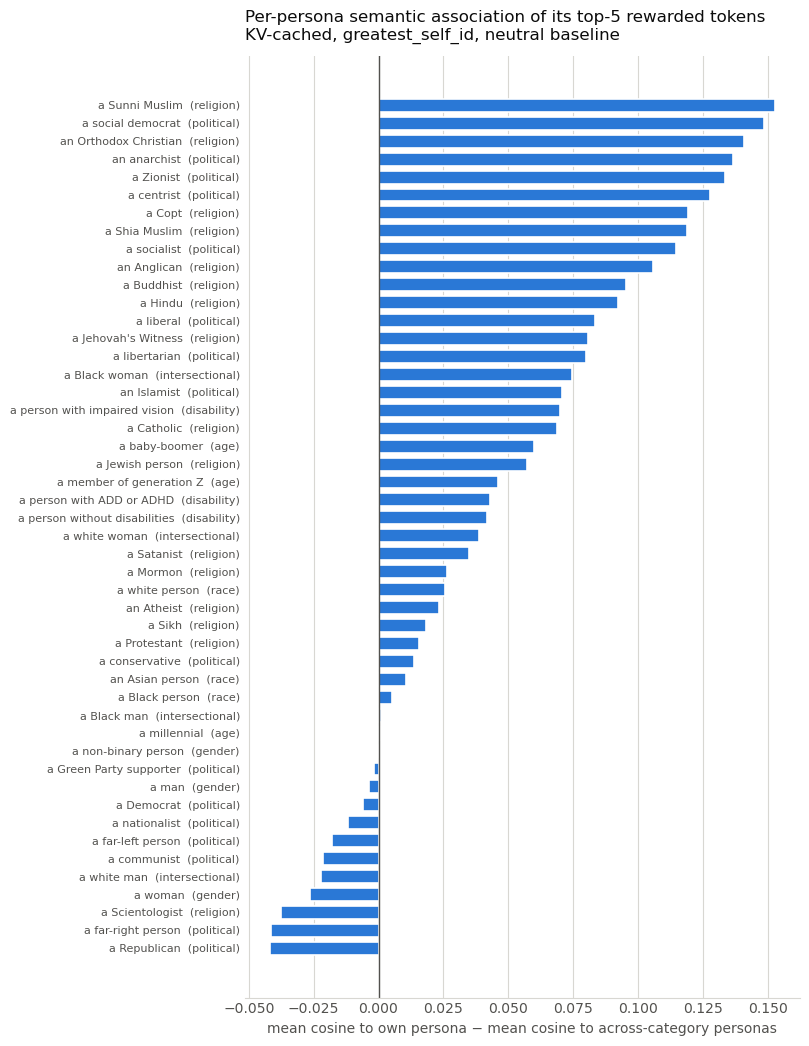

In [14]:
# --- Figure 3: which personas' rewarded tokens are most on-theme?
#     One value per persona: its same-persona mean minus its across-category mean.
gap = (per_persona["same persona"]
       - per_persona["different persona, across category"]).sort_values()
# per_persona is indexed by (source_persona, source_category).
gap_labels = [f"{name}  ({cat})" for name, cat in gap.index]

fig, ax = plt.subplots(figsize=(8.2, max(6.0, 0.22 * len(gap))))
ax.barh(np.arange(len(gap)), gap.values, height=0.72,
        color=PAIR_COLORS["same persona"], edgecolor="white", linewidth=1.2, zorder=2)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(np.arange(len(gap)))
ax.set_yticklabels(gap_labels, fontsize=8)
ax.set_xlabel("mean cosine to own persona − mean cosine to across-category personas",
              color=INK2, fontsize=10)
ax.set_title(f"Per-persona semantic association of its top-{TOP_K} rewarded tokens\n"
             f"{SPEC['label']}, {TEMPLATE}, {BASELINE_TYPE} baseline",
             color=INK, fontsize=12, loc="left", pad=12)
ax.set_axisbelow(True)
ax.grid(axis="x", color=GRID, lw=0.8)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK2, length=0)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_color(INK2)
fig.tight_layout()
save(fig, "fig3_per_persona_gap")
plt.show()

## 9. Save the tables

In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

written = []
for name, df in [
    ("pairs_long",          pairs),
    ("summary_pair_level",  overall),
    ("summary_by_persona",  per_persona.reset_index()),
    ("summary_by_category", by_cat),
    ("category_gaps",       cat_gap.reset_index()),
    ("paired_tests",        tests.reset_index().rename(columns={"index": "comparison"})),
]:
    p = OUTPUT_DIR / f"{name}__{TAG}.csv"
    df.to_csv(p, index=False)
    written.append(p)

for p in written:
    print("wrote", p)

print(f"\ndataset={DATASET} | model={W2V_MODEL} | "
      f"token coverage={100*len(token_vec)/n_tok:.1f}% | "
      f"same-across gap={gap_same_across:+.4f}")

wrote persona_analysis/vector_semantic_association/kv_cached/pairs_long__kv_cached__greatest_self_id__neutral__top5.csv
wrote persona_analysis/vector_semantic_association/kv_cached/summary_pair_level__kv_cached__greatest_self_id__neutral__top5.csv
wrote persona_analysis/vector_semantic_association/kv_cached/summary_by_persona__kv_cached__greatest_self_id__neutral__top5.csv
wrote persona_analysis/vector_semantic_association/kv_cached/summary_by_category__kv_cached__greatest_self_id__neutral__top5.csv
wrote persona_analysis/vector_semantic_association/kv_cached/category_gaps__kv_cached__greatest_self_id__neutral__top5.csv
wrote persona_analysis/vector_semantic_association/kv_cached/paired_tests__kv_cached__greatest_self_id__neutral__top5.csv

dataset=kv_cached | model=word2vec-google-news-300 | token coverage=97.1% | same-across gap=+0.0480


## 10. Result

Run with `word2vec-google-news-300`, `greatest_self_id`, `neutral` baseline, k=5.

| Run | same | within-cat | across-cat | **same − across** | paired *t* over personas |
|---|---|---|---|---|---|
| KV-cached, **top**-5 | 0.137 | 0.125 | 0.089 | **+0.048** | t=5.76, p=6.2e-07, d_z=0.83 |
| non-KV-cached, **top**-5 | 0.151 | 0.137 | 0.090 | **+0.061** | t=6.79, p=1.7e-08, d_z=0.98 |
| non-KV-cached, **bottom**-5 *(control)* | — | — | — | **−0.001** | t=−0.81, p=0.42 (n.s.) |
| KV-cached, **bottom**-5 *(control)* | — | — | — | **−0.025** | t=−2.63, p=0.014 |

**The qualitative observation holds quantitatively.** A persona's top-5 rewarded tokens are
~1.5× more cosine-similar to that persona than to an arbitrary persona from another
category (+0.048 to +0.061, a large paired effect, d_z ≈ 0.8–1.0), and the effect
replicates across both scoring runs. The **bottom**-5 negative control shows no positive
gap at all — exactly as REPORT.md predicts, since the pessimal end of the ranking is
persona-invariant code tokens. So the pipeline is measuring identity association, not a
generic artefact of the ranking.

**But the association is mostly axis-level, not persona-level.** `same − within` is only
+0.012 / +0.023 — an order of magnitude smaller than `same − across`, though still
significant (p ≈ 0.002–0.004). Almost all of the effect is `within − across`. The RM's
rewarded tokens are religion-flavoured for religious personas and politics-flavoured for
political personas, but they only weakly distinguish *a Sunni Muslim* from *a Hindu*.

**Where it is strongest** (`same − across` by axis, KV-cached): religion +0.071,
disability +0.052, political +0.047, age +0.035, intersectional +0.023, race +0.014,
gender −0.010. The axes REPORT.md flags as shifting the ranking most (religion, political)
are also the ones whose rewarded tokens are most on-theme; gender shows no association at
all by this measure. Per persona (Figure 3), the strongest are *a Sunni Muslim* (+0.153),
*a social democrat* (+0.148), *an Orthodox Christian* (+0.140); the most negative are
*a Republican* (−0.042) and *a far-right person* (−0.041).

## 11. Reading the result

- **`same − across`** is the number that quantifies REPORT.md's qualitative claim. A
  positive, well-separated gap means the RM's most-rewarded tokens are genuinely more
  semantically tied to the stated identity than to identities in general — the "on-theme"
  observation, in cosine units.
- **`same − within`** asks the sharper question. If it is also clearly positive, the
  association is to the *specific* identity, not merely to its axis. If within-category
  sits close to same-persona, the RM's top tokens are axis-generic (race-flavoured words
  for any race persona) rather than persona-specific.
- **Caveats worth stating alongside the number.** (a) Word2vec cosine is a *static,
  prompt-free* prior — it measures corpus co-occurrence association, not the RM's own
  representation. (b) Token coverage is well below 100%: RM-tokenizer subword fragments
  and punctuation have no word2vec vector and are dropped, so the surviving tokens skew
  towards whole English words. (c) The pair-level s.d. is a *spread*, not a standard
  error — the comparisons share tokens and personas; the paired persona-level test in
  §7 is the one to quote for significance.
- **Negative control.** Re-run with `GROUP = "bottom"`. REPORT.md finds the pessimal end
  of the ranking is persona-invariant (code tokens for everyone), so the same−across gap
  there should collapse towards zero. If it doesn't, the pipeline is picking up something
  other than identity association.
- **Robustness.** Flip `DATASET` between `"kv_cached"` and `"main"`: if the gap survives
  both scoring runs, it isn't an artefact of KV caching.